# LAB 02 – House Prices: Advanced Regression Techniques

**Mục tiêu:** xây dựng mô hình hồi quy dự đoán `SalePrice` theo quy trình CRISP-DM, từ hiểu bài toán → hiểu/khám phá dữ liệu → tiền xử lý & feature engineering → modeling/tuning → đánh giá → tạo file submission Kaggle.

# So lets begin with complete EDA...

In [2]:
import pandas as pd 
import numpy as np
import matplotlib. pyplot as plt
import seaborn as sns
import pickle

In [3]:
import os

print("Current directory:", os.getcwd())
print(os.listdir())

Current directory: c:\Users\Admin\Documents\GitHub\sgu26MAYHOC\sgu-MAYHOC\lab02\data
['.keep', 'data_description.txt', 'lab02_house_price_CRISP.ipynb', 'sample_submission.csv', 'test.csv', 'train.csv']


# Load Data

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [5]:
print(train. info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
print(test. info())

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

# Train Data

In [7]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


# Test Data

In [8]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

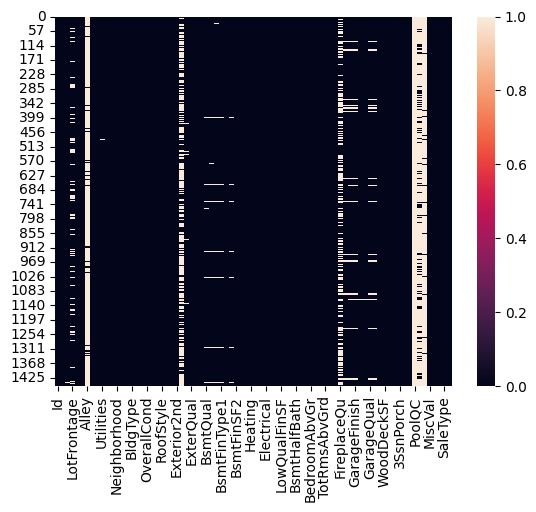

In [10]:
sns.heatmap(test.isnull())

# For Train Data

In [13]:
cat_col_train= ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond']
ncat_col_train= ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i]=train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j]=train[j].fillna(train[j].mean())

# For Test Data

In [15]:
cat_col_train= ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_train= ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for i in cat_col_train:
    test[i]=train[i].fillna(test[i].mode()[0])

for j in ncat_col_train:
    test[j]=test[j].fillna(test[j].mean())